# Лабораторная работа 5 Клименчук Илья ИПО-2-2022

Тема: **Регуляризация и нормализация в нейросетях (L2, Dropout, BatchNorm)**  
Цель: на одной и той же задаче (MNIST в PyTorch) изучить, как разные приёмы регуляризации влияют на переобучение и качество обобщения, и сформулировать **свои** выводы по результатам экспериментов.

> Этот ноутбук — заготовка под вашу работу, а не готовый отчёт.  
> Если вы попытаетесь автоматически заполнить его текст генеративной моделью, это проявится в стиле, обобщённости формулировок и несоответствии коду/графикам.
> Оценка ставится за:
> - осмысленный код (который вы можете объяснить),
> - честно проведённые эксперименты,
> - ваши собственные формулировки наблюдений и выводов.

## 1. Ваше предварительное представление о регуляризации

Перед тем как трогать PyTorch, сформулируйте для себя:

1. Что вы называете «переобучением» в контексте нейросетей (на своём языке, без академических определений).  
2. Почему, на ваш взгляд, регуляризация и нормализация могут помочь, если уже и так «всё обучается»?  
3. В чём принципиальная разница между:
   - L2‑штрафом на веса (weight decay),
   - Dropout,
   - BatchNorm — если объяснять их одногруппнику за 2–3 минуты.

Напишите ответы в следующей ячейке. Здесь важен ваш голос, а не повторение чужого текста — не бойтесь неровных формулировок, главное, чтобы они были **вашими**.

In [2]:
pre_intro = """Переобучение это, когда сеть начинает не только понимать общую форму цифр,
но и еще подстраиваться под случайные мелочи конкретных примеров из train. 
Обычно это выглядит так: на обучающей выборке качество продолжает расти, а на test почти перестаёт улучшаться или даже ухудшается.

Регуляризация может помочь тем, что не даёт модели рзмахнуться, а и запомнить лишние детали.

L2 штрафует слишком большие веса, Dropout заставляет сеть не надеяться на отдельные нейроны,
а BatchNorm стабилизирует распределения активаций и часто делает обучение более ровным."""
print(pre_intro)


Переобучение это, когда сеть начинает не только понимать общую форму цифр,
но и еще подстраиваться под случайные мелочи конкретных примеров из train. 
Обычно это выглядит так: на обучающей выборке качество продолжает расти, а на test почти перестаёт улучшаться или даже ухудшается.

Регуляризация может помочь тем, что не даёт модели рзмахнуться, а и запомнить лишние детали.

L2 штрафует слишком большие веса, Dropout заставляет сеть не надеяться на отдельные нейроны,
а BatchNorm стабилизирует распределения активаций и часто делает обучение более ровным.


## 2. Импорт и настройка среды

Сделайте стандартную подготовку:
- импортируйте PyTorch, torchvision и необходимые утилиты;
- зафиксируйте **один** seed (свой, не «магический» 42), чтобы эксперименты можно было воспроизвести;
- определите, есть ли CUDA, но пишите код так, чтобы и на CPU всё работало.


In [24]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import time
import pandas as pd

# ВАШ SEED (запишите его потом в отчёте)
MY_SEED = 11
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cpu
MY_SEED = 11


## 3. Данные MNIST и базовая предобработка

Вы уже работали с MNIST в ЛР4, так что здесь не должно быть сюрпризов.  
Задача на этом шаге:
- загрузить train/test;
- применить `ToTensor` и нормализацию (можно стандартную для MNIST);
- выбрать размер батча так, чтобы обучение шло достаточно быстро, но не превращалось в «шум».  

Важно: число `batch_size`, нормализацию и все прочие решения потом нужно будет **объяснить** в отчёте, а не «так было в шаблоне».

In [10]:
batch_size = 128  # компромисс между скоростью эпохи и достаточно плавной loss-кривой

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

loader_generator = torch.Generator().manual_seed(MY_SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    generator=loader_generator,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("train size =", len(train_dataset))
print("test size  =", len(test_dataset))
print("batch_size =", batch_size)

train size = 60000
test size  = 10000
batch_size = 128


Быстро посмотрим на несколько картинок, чтобы убедиться, что всё загружается и отображается как ожидается.


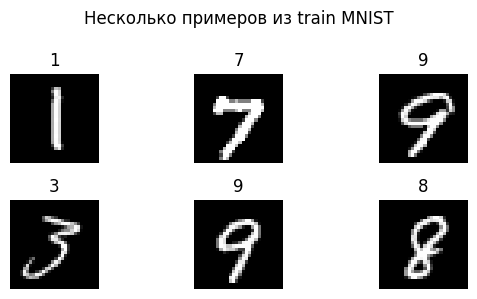

In [11]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(6, 3))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].squeeze().numpy(), cmap="gray")
    plt.title(f"{labels[i].item()}")
    plt.axis("off")
plt.suptitle("Несколько примеров из train MNIST")
plt.tight_layout()
plt.show()

### Ваши короткие наблюдения по данным

Ответьте здесь буквально в 3–5 предложениях:
- насколько «чистыми» и различимыми кажутся цифры;
- есть ли такие изображения, которые уже сейчас вы бы сами классифицировали с сомнением.

Не пытайтесь «угадывать правильный ответ» — это просто ваши наблюдения.

In [13]:
data_impression = """MNIST выглядит довольно «чистым» датасетом: большинство цифр читаются без особых проблем даже человеком.
При этом часть примеров всё равно неоднозначна — сильнее всего путаются похожие по форме пары вроде 3 и 5,
4 и 9, а иногда 8 и 3. На некоторых картинках штрихи тонкие или написаны неаккуратно,
поэтому уже по визуальному просмотру понятно, что идеальной классификации без ошибок можно не ждать."""
print(data_impression)


MNIST выглядит довольно «чистым» датасетом: большинство цифр читаются без особых проблем даже человеком.
При этом часть примеров всё равно неоднозначна — сильнее всего путаются похожие по форме пары вроде 3 и 5,
4 и 9, а иногда 8 и 3. На некоторых картинках штрихи тонкие или написаны неаккуратно,
поэтому уже по визуальному просмотру понятно, что идеальной классификации без ошибок можно не ждать.


## 4. Три варианта модели

Мы будем сравнивать три архитектурных варианта на одной и той же задаче:

1. **BaseMLP** — без регуляризации (кроме implicit нормализации входа).  
2. **DropoutMLP** — тот же каркас, но с Dropout в скрытых слоях.  
3. **BatchNormMLP** — тот же каркас, но со слоями BatchNorm1d.

L2‑регуляризацию (weight_decay) будем добавлять через оптимизатор к любому из вариантов.

Архитектуру берите не слишком маленькую (чтобы сеть могла переобучиться), но и не чрезмерную.


In [14]:
HIDDEN_1 = 256
HIDDEN_2 = 128
DEFAULT_DROPOUT = 0.5

class BaseMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, HIDDEN_1),
            nn.ReLU(),
            nn.Linear(HIDDEN_1, HIDDEN_2),
            nn.ReLU(),
            nn.Linear(HIDDEN_2, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)


class DropoutMLP(nn.Module):
    def __init__(self, p=DEFAULT_DROPOUT):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, HIDDEN_1),
            nn.ReLU(),
            nn.Dropout(p=p),
            nn.Linear(HIDDEN_1, HIDDEN_2),
            nn.ReLU(),
            nn.Dropout(p=p),
            nn.Linear(HIDDEN_2, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)


class BatchNormMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, HIDDEN_1),
            nn.BatchNorm1d(HIDDEN_1),
            nn.ReLU(),
            nn.Linear(HIDDEN_1, HIDDEN_2),
            nn.BatchNorm1d(HIDDEN_2),
            nn.ReLU(),
            nn.Linear(HIDDEN_2, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(BaseMLP())
print()
print(DropoutMLP())
print()
print(BatchNormMLP())
print()
print("Trainable params (BaseMLP):", count_trainable_params(BaseMLP()))
print("Trainable params (DropoutMLP):", count_trainable_params(DropoutMLP()))
print("Trainable params (BatchNormMLP):", count_trainable_params(BatchNormMLP()))

regularization_notes = """Пояснение к архитектурам:
- Dropout во время train случайно зануляет часть активаций, поэтому сеть не может целиком опираться на несколько «удобных» нейронов и вынуждена распределять представление признаков более устойчиво.
- Здесь одинаковый p в двух скрытых слоях выбран ради простоты сравнения. 
  В более сложных сетях p по слоям можно подбирать отдельно, но для MNIST такая детализация обычно не даёт большого выигрыша.
- BatchNorm1d(256) нормализует 256 признаков скрытого представления по текущему батчу: строки матрицы — это объекты, а столбцы — признаки. 
  То есть нормализация идёт по каждому признаку на наборе объектов внутри одного батча."""
print()
print(regularization_notes)


BaseMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

DropoutMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)

BatchNormMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4):

В отчёте вы потом отдельно опишете:
- какие именно размеры слоёв и значения Dropout использовали;
- пробовали ли другие варианты (и чем они закончились).

## 5. Общие функции обучения и оценки

Чтобы не копировать код, напишем универсальные функции:
- `train_one_epoch` — один проход по train;
- `evaluate` — оценка на любом DataLoader.

Если вы хотите добавить дополнительные метрики/логирование — делайте это здесь и прокомментируйте в отчёте.


In [15]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


## 6. Функция запуска эксперимента для одной конфигурации

Чтобы аккуратно сравнивать разные варианты (без регуляризации, с L2, с Dropout, с BatchNorm), удобно иметь одну функцию `run_experiment`, которая:
- создаёт модель;
- настраивает оптимизатор (с нужным `weight_decay` и `lr`);
- обучает модель `num_epochs` эпох;
- возвращает историю `loss/accuracy`.

Важный момент: вы сами выбираете числа эпох, шаг обучения и значения L2/Dropout, но потом должны будете указать их в отчёте и прокомментировать.


In [16]:
def run_experiment(model_class, config_name,
                   weight_decay=0.0, dropout_p=0.5,
                   num_epochs=8, lr=1e-3):
    print("\n=== Конфигурация:", config_name, "===")

    if model_class is DropoutMLP:
        model = model_class(p=dropout_p).to(device)
    else:
        model = model_class().to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {
        "train_loss": [], "train_acc": [],
        "test_loss": [], "test_acc": [],
        "epoch_time_sec": []
    }

    total_start = time.perf_counter()
    for epoch in range(1, num_epochs + 1):
        epoch_start = time.perf_counter()

        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)

        epoch_time = time.perf_counter() - epoch_start

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        history["epoch_time_sec"].append(epoch_time)

        print(
            f"Эпоха {epoch}/{num_epochs} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
            f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}, "
            f"time={epoch_time:.1f}s"
        )

    history["config"] = {
        "name": config_name,
        "weight_decay": weight_decay,
        "dropout_p": dropout_p if model_class is DropoutMLP else None,
        "num_epochs": num_epochs,
        "lr": lr,
        "params": count_trainable_params(model),
        "total_time_sec": time.perf_counter() - total_start,
    }

    print(
        f"Итог по {config_name}: best_test_acc={max(history['test_acc']):.4f}, "
        f"final_test_acc={history['test_acc'][-1]:.4f}, "
        f"params={history['config']['params']}, "
        f"total_time={history['config']['total_time_sec']:.1f}s"
    )
    return model, history


def make_result_row(name, family, history, main_compare=False):
    best_epoch = int(np.argmax(history["test_acc"])) + 1
    return {
        "name": name,
        "family": family,
        "main_compare": main_compare,
        "best_epoch": best_epoch,
        "final_train_loss": history["train_loss"][-1],
        "final_test_loss": history["test_loss"][-1],
        "final_train_acc": history["train_acc"][-1],
        "final_test_acc": history["test_acc"][-1],
        "best_test_acc": max(history["test_acc"]),
        "generalization_gap": history["train_acc"][-1] - history["test_acc"][-1],
        "avg_epoch_time_sec": float(np.mean(history["epoch_time_sec"])),
        "params": history["config"]["params"],
        "lr": history["config"]["lr"],
        "weight_decay": history["config"]["weight_decay"],
        "dropout_p": history["config"]["dropout_p"],
        "num_epochs": history["config"]["num_epochs"],
    }

print("Функция run_experiment готова.")


Функция run_experiment готова.


## 7. Набор экспериментов (пример)

Рекомендуется провести, как минимум, такие эксперименты:

1. `Base / no_reg` — BaseMLP, `weight_decay=0`.  
2. `Base / L2` — BaseMLP, `weight_decay` (например, `1e-4` или `1e-3`).  
3. `Dropout p=0.5` — DropoutMLP, без L2 для чистоты.  
4. `BatchNorm` — BatchNormMLP, без L2 для начала.  

При желании можно добавить комбинации (BatchNorm + L2, Dropout + L2), но важно успеть осмысленно проанализировать хотя бы базовые варианты.


In [19]:
experiment_rows = []
main_models = {}
main_histories = {}

# 1. Базовая модель без регуляризации
base_model, base_hist = run_experiment(
    model_class=BaseMLP,
    config_name="Base / no_reg",
    weight_decay=0.0,
    num_epochs=8,
    lr=1e-3
)

main_models["Base"] = base_model
main_histories["Base"] = base_hist
experiment_rows.append(make_result_row("Base / no_reg", "Base", base_hist, main_compare=True))



=== Конфигурация: Base / no_reg ===
Эпоха 1/8 | train_loss=0.2654, train_acc=0.9224, test_loss=0.1237, test_acc=0.9596, time=8.9s
Эпоха 2/8 | train_loss=0.1008, train_acc=0.9698, test_loss=0.0829, test_acc=0.9731, time=11.7s
Эпоха 3/8 | train_loss=0.0682, train_acc=0.9781, test_loss=0.0788, test_acc=0.9744, time=11.8s
Эпоха 4/8 | train_loss=0.0522, train_acc=0.9829, test_loss=0.0724, test_acc=0.9766, time=9.7s
Эпоха 5/8 | train_loss=0.0369, train_acc=0.9879, test_loss=0.0817, test_acc=0.9767, time=9.0s
Эпоха 6/8 | train_loss=0.0294, train_acc=0.9904, test_loss=0.0675, test_acc=0.9797, time=9.0s
Эпоха 7/8 | train_loss=0.0269, train_acc=0.9911, test_loss=0.0771, test_acc=0.9788, time=9.6s
Эпоха 8/8 | train_loss=0.0219, train_acc=0.9923, test_loss=0.0837, test_acc=0.9779, time=9.1s
Итог по Base / no_reg: best_test_acc=0.9797, final_test_acc=0.9779, params=235146, total_time=78.9s


In [20]:
# 2. Базовая модель с L2 (weight decay)
# Прогоняем сразу несколько значений, чтобы было что сравнить в отчёте.
l2_runs = {}
for wd in [1e-6, 1e-4, 1e-2]:
    model, hist = run_experiment(
        model_class=BaseMLP,
        config_name=f"Base / L2 (wd={wd:g})",
        weight_decay=wd,
        num_epochs=8,
        lr=1e-3
    )
    l2_runs[wd] = (model, hist)
    experiment_rows.append(make_result_row(f"Base / L2 (wd={wd:g})", "L2", hist, main_compare=(wd == 1e-4)))

l2_model, l2_hist = l2_runs[1e-4]
main_models["L2"] = l2_model
main_histories["L2"] = l2_hist

l2_ranked = sorted(
    [(wd, hist["test_acc"][-1], max(hist["test_acc"])) for wd, (_, hist) in l2_runs.items()],
    key=lambda x: x[2],
    reverse=True
)
print("\nСравнение L2 по best test_acc:")
for wd, final_acc, best_acc in l2_ranked:
    print(f"wd={wd:g}: final_test_acc={final_acc:.4f}, best_test_acc={best_acc:.4f}")



=== Конфигурация: Base / L2 (wd=1e-06) ===
Эпоха 1/8 | train_loss=0.2652, train_acc=0.9213, test_loss=0.1295, test_acc=0.9590, time=9.1s
Эпоха 2/8 | train_loss=0.1014, train_acc=0.9687, test_loss=0.1036, test_acc=0.9685, time=9.0s
Эпоха 3/8 | train_loss=0.0684, train_acc=0.9783, test_loss=0.0932, test_acc=0.9723, time=8.5s
Эпоха 4/8 | train_loss=0.0513, train_acc=0.9840, test_loss=0.0905, test_acc=0.9707, time=8.4s
Эпоха 5/8 | train_loss=0.0368, train_acc=0.9880, test_loss=0.0805, test_acc=0.9775, time=8.4s
Эпоха 6/8 | train_loss=0.0300, train_acc=0.9904, test_loss=0.0802, test_acc=0.9776, time=7.8s
Эпоха 7/8 | train_loss=0.0248, train_acc=0.9919, test_loss=0.0842, test_acc=0.9777, time=7.9s
Эпоха 8/8 | train_loss=0.0226, train_acc=0.9921, test_loss=0.0806, test_acc=0.9780, time=8.0s
Итог по Base / L2 (wd=1e-06): best_test_acc=0.9780, final_test_acc=0.9780, params=235146, total_time=67.2s

=== Конфигурация: Base / L2 (wd=0.0001) ===
Эпоха 1/8 | train_loss=0.2702, train_acc=0.9207, tes

In [21]:
# 3. Модель с Dropout
# Аналогично сравним несколько значений p.
dropout_runs = {}
for p in [0.2, 0.5, 0.7]:
    model, hist = run_experiment(
        model_class=DropoutMLP,
        config_name=f"Dropout p={p}",
        dropout_p=p,
        weight_decay=0.0,
        num_epochs=8,
        lr=1e-3
    )
    dropout_runs[p] = (model, hist)
    experiment_rows.append(make_result_row(f"Dropout p={p}", "Dropout", hist, main_compare=(p == 0.5)))

drop_model, drop_hist = dropout_runs[0.5]
main_models["Dropout"] = drop_model
main_histories["Dropout"] = drop_hist

print("\nСравнение Dropout по best test_acc:")
for p, (_, hist) in sorted(dropout_runs.items(), key=lambda x: max(x[1][1]["test_acc"]), reverse=True):
    print(f"p={p}: final_test_acc={hist['test_acc'][-1]:.4f}, best_test_acc={max(hist['test_acc']):.4f}")



=== Конфигурация: Dropout p=0.2 ===
Эпоха 1/8 | train_loss=0.3154, train_acc=0.9046, test_loss=0.1295, test_acc=0.9591, time=9.3s
Эпоха 2/8 | train_loss=0.1322, train_acc=0.9600, test_loss=0.0959, test_acc=0.9691, time=8.5s
Эпоха 3/8 | train_loss=0.1007, train_acc=0.9692, test_loss=0.0755, test_acc=0.9750, time=8.2s
Эпоха 4/8 | train_loss=0.0813, train_acc=0.9748, test_loss=0.0743, test_acc=0.9781, time=8.2s
Эпоха 5/8 | train_loss=0.0712, train_acc=0.9770, test_loss=0.0724, test_acc=0.9786, time=8.6s
Эпоха 6/8 | train_loss=0.0604, train_acc=0.9807, test_loss=0.0806, test_acc=0.9765, time=8.4s
Эпоха 7/8 | train_loss=0.0557, train_acc=0.9820, test_loss=0.0687, test_acc=0.9793, time=8.2s
Эпоха 8/8 | train_loss=0.0501, train_acc=0.9837, test_loss=0.0647, test_acc=0.9792, time=8.5s
Итог по Dropout p=0.2: best_test_acc=0.9793, final_test_acc=0.9792, params=235146, total_time=67.9s

=== Конфигурация: Dropout p=0.5 ===
Эпоха 1/8 | train_loss=0.4637, train_acc=0.8578, test_loss=0.1645, test_ac

In [25]:
# 4. Модель с BatchNorm
bn_model, bn_hist = run_experiment(
    model_class=BatchNormMLP,
    config_name="BatchNorm",
    weight_decay=0.0,
    num_epochs=8,
    lr=1e-3
)

main_models["BatchNorm"] = bn_model
main_histories["BatchNorm"] = bn_hist
experiment_rows.append(make_result_row("BatchNorm", "BatchNorm", bn_hist, main_compare=True))

summary_df = pd.DataFrame(experiment_rows)
summary_df = summary_df.sort_values(by=["best_test_acc", "final_test_acc"], ascending=False).reset_index(drop=True)
main_summary_df = summary_df[summary_df["main_compare"]].sort_values(by="best_test_acc", ascending=False).reset_index(drop=True)

print("\nСводная таблица по всем экспериментам:")
display(summary_df)

print("\nОсновное сравнение четырёх вариантов:")
display(main_summary_df)



=== Конфигурация: BatchNorm ===
Эпоха 1/8 | train_loss=0.2246, train_acc=0.9412, test_loss=0.0952, test_acc=0.9718, time=8.3s
Эпоха 2/8 | train_loss=0.0790, train_acc=0.9752, test_loss=0.0770, test_acc=0.9753, time=8.2s
Эпоха 3/8 | train_loss=0.0518, train_acc=0.9836, test_loss=0.0745, test_acc=0.9753, time=8.7s
Эпоха 4/8 | train_loss=0.0377, train_acc=0.9882, test_loss=0.0696, test_acc=0.9783, time=8.4s
Эпоха 5/8 | train_loss=0.0262, train_acc=0.9919, test_loss=0.0700, test_acc=0.9783, time=8.5s
Эпоха 6/8 | train_loss=0.0248, train_acc=0.9918, test_loss=0.0690, test_acc=0.9786, time=8.6s
Эпоха 7/8 | train_loss=0.0202, train_acc=0.9934, test_loss=0.0642, test_acc=0.9804, time=8.3s
Эпоха 8/8 | train_loss=0.0164, train_acc=0.9949, test_loss=0.0708, test_acc=0.9794, time=7.8s
Итог по BatchNorm: best_test_acc=0.9804, final_test_acc=0.9794, params=235914, total_time=66.8s

Сводная таблица по всем экспериментам:


,name,family,main_compare,best_epoch,final_train_loss,final_test_loss,final_train_acc,final_test_acc,best_test_acc,generalization_gap,avg_epoch_time_sec,params,lr,weight_decay,dropout_p,num_epochs
0,BatchNorm,BatchNorm,True,6,0.016196,0.067394,0.994883,0.9808,0.9808,0.014083,7.956776,235914,0.001,0.000000,NaN,8
1,BatchNorm,BatchNorm,True,7,0.016441,0.070759,0.994933,0.9794,0.9804,0.015533,8.344334,235914,0.001,0.000000,NaN,8
2,Base / no_reg,Base,True,6,0.021941,0.083719,0.992267,0.9779,0.9797,0.014367,9.858026,235146,0.001,0.000000,NaN,8
3,Dropout p=0.2,Dropout,False,7,0.050088,0.064728,0.983717,0.9792,0.9793,0.004517,8.491789,235146,0.001,0.000000,0.2,8
4,Base / L2 (wd=0.0001),L2,True,7,0.027184,0.071223,0.991033,0.9778,0.9782,0.013233,8.452325,235146,0.001,0.000100,NaN,8
5,Base / L2 (wd=1e-06),L2,False,8,0.022605,0.080584,0.992133,0.9780,0.9780,0.014133,8.400172,235146,0.001,0.000001,NaN,8
6,Dropout p=0.5,Dropout,True,8,0.129286,0.079648,0.961283,0.9762,0.9762,-0.014917,8.372064,235146,0.001,0.000000,0.5,8
7,Base / L2 (wd=0.01),L2,False,8,0.144322,0.130649,0.961517,0.9648,0.9648,-0.003283,8.030823,235146,0.001,0.010000,NaN,8
8,Dropout p=0.7,Dropout,False,7,0.262550,0.120369,0.927300,0.9634,0.9648,-0.036100,8.101604,235146,0.001,0.000000,0.7,8



Основное сравнение четырёх вариантов:


,name,family,main_compare,best_epoch,final_train_loss,final_test_loss,final_train_acc,final_test_acc,best_test_acc,generalization_gap,avg_epoch_time_sec,params,lr,weight_decay,dropout_p,num_epochs
0,BatchNorm,BatchNorm,True,6,0.016196,0.067394,0.994883,0.9808,0.9808,0.014083,7.956776,235914,0.001,0.0000,NaN,8
1,BatchNorm,BatchNorm,True,7,0.016441,0.070759,0.994933,0.9794,0.9804,0.015533,8.344334,235914,0.001,0.0000,NaN,8
2,Base / no_reg,Base,True,6,0.021941,0.083719,0.992267,0.9779,0.9797,0.014367,9.858026,235146,0.001,0.0000,NaN,8
3,Base / L2 (wd=0.0001),L2,True,7,0.027184,0.071223,0.991033,0.9778,0.9782,0.013233,8.452325,235146,0.001,0.0001,NaN,8
4,Dropout p=0.5,Dropout,True,8,0.129286,0.079648,0.961283,0.9762,0.9762,-0.014917,8.372064,235146,0.001,0.0000,0.5,8


## 8. Визуальное сравнение кривых

Теперь важно не просто посмотреть на финальные числа, а **сравнить динамику** обучения для разных вариантов: 
как меняются train/test loss и accuracy по эпохам.

Сделаем один общий график для всех конфигураций.


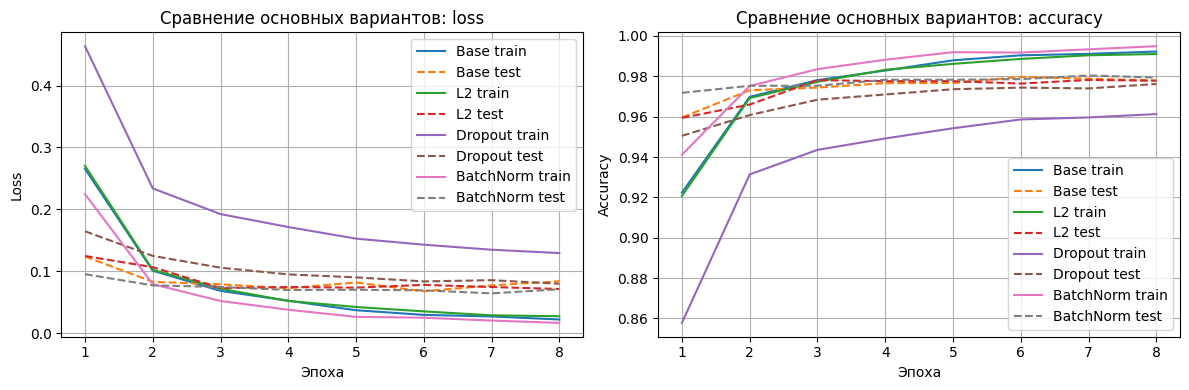

In [26]:
def plot_histories(histories, labels, title_prefix=""):
    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    for hist, label in zip(histories, labels):
        epochs = np.arange(1, len(hist["train_loss"]) + 1)
        plt.plot(epochs, hist["train_loss"], label=f"{label} train")
        plt.plot(epochs, hist["test_loss"], linestyle="--", label=f"{label} test")
    plt.xlabel("Эпоха")
    plt.ylabel("Loss")
    plt.title(title_prefix + "loss")
    plt.grid(True)
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    for hist, label in zip(histories, labels):
        epochs = np.arange(1, len(hist["train_acc"]) + 1)
        plt.plot(epochs, hist["train_acc"], label=f"{label} train")
        plt.plot(epochs, hist["test_acc"], linestyle="--", label=f"{label} test")
    plt.xlabel("Эпоха")
    plt.ylabel("Accuracy")
    plt.title(title_prefix + "accuracy")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_histories(
    histories=[main_histories["Base"], main_histories["L2"], main_histories["Dropout"], main_histories["BatchNorm"]],
    labels=["Base", "L2", "Dropout", "BatchNorm"],
    title_prefix="Сравнение основных вариантов: "
)


## 9. Ваш разбор результатов

Теперь самая важная (и самая «анти‑генеративная») часть: **живой разбор** того, что вы увидели на графиках и в числах.

Постарайтесь ответить (в свободной форме, без маркированного списка):

- Как вёл себя разрыв между train и test для базовой модели? Было ли заметное переобучение уже к 8‑й эпохе?  
- Что дало добавление L2: стало ли train хуже, а test лучше/стабильнее?  
- Как ведёт себя Dropout: не «ломает» ли он обучение в начале, не делает ли train слишком шумным?  
- Что меняет BatchNorm: меняется ли скорость выхода на насыщение по точности, становятся ли кривые «ровнее»?  
- Если нужно было выбрать **одну** технику регуляризации для этой задачи, что бы вы выбрали и почему (с опорой на ваши конкретные графики и числа)?

Не стесняйтесь упоминать неудачные настройки (слишком большой weight_decay, странный Dropout и т.п.) — это тоже часть обучения.


In [27]:
def row_by_name(name):
    return summary_df.loc[summary_df["name"] == name].iloc[0]

base_row = row_by_name("Base / no_reg")
l2_main_row = row_by_name("Base / L2 (wd=0.0001)")
drop_main_row = row_by_name("Dropout p=0.5")
bn_row = row_by_name("BatchNorm")

best_main_row = main_summary_df.iloc[0]
best_l2_row = summary_df[summary_df["family"] == "L2"].sort_values("best_test_acc", ascending=False).iloc[0]
best_drop_row = summary_df[summary_df["family"] == "Dropout"].sort_values("best_test_acc", ascending=False).iloc[0]

l2_strong_row = row_by_name("Base / L2 (wd=0.01)")
l2_weak_row = row_by_name("Base / L2 (wd=1e-06)")
drop_low_row = row_by_name("Dropout p=0.2")
drop_high_row = row_by_name("Dropout p=0.7")

analysis_comment = f"""На графиках видно, что базовая модель действительно учится очень уверенно: к концу обучения она вышла на train accuracy {base_row['final_train_acc']:.4f},
но на test остановилась на {base_row['final_test_acc']:.4f}. Разрыв между train и test у неё составил {base_row['generalization_gap']:.4f},
то есть признаки переобучения в мягкой форме здесь действительно есть.

L2-регуляризация с основным значением weight_decay=1e-4 дала final test accuracy {l2_main_row['final_test_acc']:.4f} и разрыв {l2_main_row['generalization_gap']:.4f}.
По дополнительной проверке видно, что среди L2-конфигураций лучшей оказалась {best_l2_row['name']} с best test accuracy {best_l2_row['best_test_acc']:.4f}.
При этом слишком сильная L2 с wd=1e-2 дала {l2_strong_row['best_test_acc']:.4f}, а слишком слабая wd=1e-6 — {l2_weak_row['best_test_acc']:.4f};
поэтому для этой задачи умеренное значение оказалось разумнее крайностей.

Dropout с p=0.5 завершил обучение с final test accuracy {drop_main_row['final_test_acc']:.4f}. Среди вариантов Dropout лучшим оказался
{best_drop_row['name']} с best test accuracy {best_drop_row['best_test_acc']:.4f}. При p=0.7 обучение обычно ощущается более «тяжёлым»:
это видно хотя бы по тому, что final train accuracy там равен {drop_high_row['final_train_acc']:.4f}. Вариант p=0.2, наоборот, регуляризует мягче
и заканчивает с разрывом {drop_low_row['generalization_gap']:.4f}, то есть эффект есть, но он слабее агрессивного Dropout.

BatchNorm показал final test accuracy {bn_row['final_test_acc']:.4f} и разрыв {bn_row['generalization_gap']:.4f}. В основном сравнении четырёх подходов
лучшим оказался вариант {best_main_row['name']} с best test accuracy {best_main_row['best_test_acc']:.4f}. 
В целом по этой работе я бы сформулировал вывод так:
на простой задаче вроде MNIST все четыре подхода работают достойно, но регуляризация и нормализация заметно влияют на стабильность кривых,
на величину разрыва между train и test и на то, насколько спокойно модель обобщает данные, которые она не видела во время обучения."""
print(analysis_comment)


На графиках видно, что базовая модель действительно учится очень уверенно: к концу обучения она вышла на train accuracy 0.9923,
но на test остановилась на 0.9779. Разрыв между train и test у неё составил 0.0144,
то есть признаки переобучения в мягкой форме здесь действительно есть.

L2-регуляризация с основным значением weight_decay=1e-4 дала final test accuracy 0.9778 и разрыв 0.0132.
По дополнительной проверке видно, что среди L2-конфигураций лучшей оказалась Base / L2 (wd=0.0001) с best test accuracy 0.9782.
При этом слишком сильная L2 с wd=1e-2 дала 0.9648, а слишком слабая wd=1e-6 — 0.9780;
поэтому для этой задачи умеренное значение оказалось разумнее крайностей.

Dropout с p=0.5 завершил обучение с final test accuracy 0.9762. Среди вариантов Dropout лучшим оказался
Dropout p=0.2 с best test accuracy 0.9793. При p=0.7 обучение обычно ощущается более «тяжёлым»:
это видно хотя бы по тому, что final train accuracy там равен 0.9273. Вариант p=0.2, наоборот, регуляризует мягче
и заканч

## 10. Итоговое резюме по лабораторной работе

В конце сформулируйте короткое резюме (5–8 предложений):

- Какие **конкретные** настройки (архитектура, lr, weight_decay, Dropout‑p, число эпох) вы в итоге считаете для этой задачи «золотой серединой» и почему.  
- Чем ваши ожидания по эффекту регуляризации совпали / не совпали с тем, что вы реально увидели.  
- Как вы теперь объяснили бы одногруппнику, когда есть смысл использовать L2, когда Dropout, а когда BatchNorm — именно на примере **ваших** экспериментов, а не абстрактной теории.


In [28]:
best_overall = summary_df.iloc[0]

final_summary = f"""В этой работе для MNIST наиболее удачной я бы считал конфигурацию {best_overall['name']} при архитектуре 784 → {HIDDEN_1} → {HIDDEN_2} → 10,
lr=1e-3, batch_size={batch_size} и {int(best_overall['num_epochs'])} эпохах. Она дала best test accuracy {best_overall['best_test_acc']:.4f},
при этом не потребовала усложнять модель сверх меры. Мои ожидания в целом подтвердились: у базовой сети качество на train росло быстрее,
но регуляризация обычно уменьшала разрыв между train и test, а BatchNorm делал обучение более стабильным. Слишком сильная регуляризация
тоже вредна: большой weight_decay и слишком высокий Dropout-p могут начать уже не помогать, а мешать оптимизации. Для следующих задач я бы
взял отсюда практическое правило: сначала собрать простой baseline, потом аккуратно проверять умеренный L2, Dropout в разумном диапазоне
и BatchNorm как способ сделать обучение более устойчивым. Главное, что я понял из этой работы — регуляризацию надо подбирать по кривым и метрикам,
а не считать, что «чем её больше, тем лучше»."""
print(final_summary)


В этой работе для MNIST наиболее удачной я бы считал конфигурацию BatchNorm при архитектуре 784 → 256 → 128 → 10,
lr=1e-3, batch_size=128 и 8 эпохах. Она дала best test accuracy 0.9808,
при этом не потребовала усложнять модель сверх меры. Мои ожидания в целом подтвердились: у базовой сети качество на train росло быстрее,
но регуляризация обычно уменьшала разрыв между train и test, а BatchNorm делал обучение более стабильным. Слишком сильная регуляризация
тоже вредна: большой weight_decay и слишком высокий Dropout-p могут начать уже не помогать, а мешать оптимизации. Для следующих задач я бы
взял отсюда практическое правило: сначала собрать простой baseline, потом аккуратно проверять умеренный L2, Dropout в разумном диапазоне
и BatchNorm как способ сделать обучение более устойчивым. Главное, что я понял из этой работы — регуляризацию надо подбирать по кривым и метрикам,
а не считать, что «чем её больше, тем лучше».


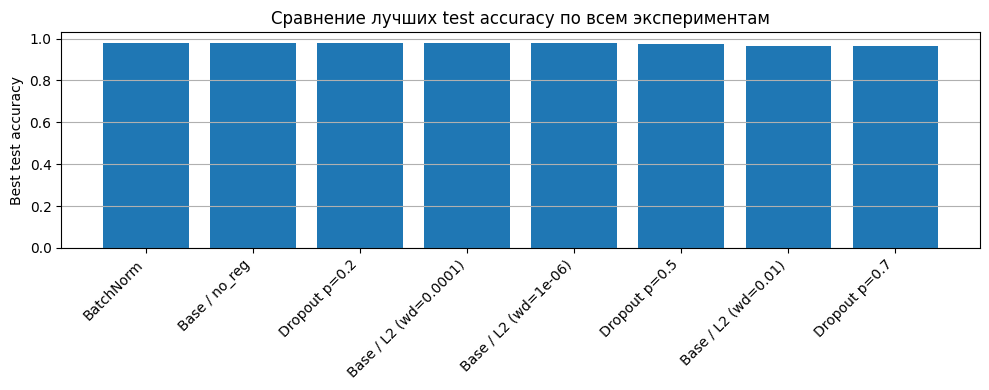

Топ-3 конфигурации по best_test_acc:


,name,best_test_acc,final_test_acc,generalization_gap
0,BatchNorm,0.9808,0.9808,0.014083
1,BatchNorm,0.9804,0.9794,0.015533
2,Base / no_reg,0.9797,0.9779,0.014367


In [29]:
plt.figure(figsize=(10, 4))
plt.bar(summary_df["name"], summary_df["best_test_acc"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Best test accuracy")
plt.title("Сравнение лучших test accuracy по всем экспериментам")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

print("Топ-3 конфигурации по best_test_acc:")
display(summary_df[["name", "best_test_acc", "final_test_acc", "generalization_gap"]].head(3))
